# Proyecto 2 NLP

**Universidad del Valle de Guatemala**  
**Facultad de Ingeniería**  
**Departamento de Ciencias de la Computación**  
**Procesamiento de Lenguaje Natural**   

## Integrantes: 
- Pablo Orellana
- Diego Leiva
- Renatto Guzmán

In [5]:
!pip3.10 install spacy

     ---------------------------------------- 0.0/15.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.3 MB 1.3 MB/s eta 0:00:12
     --------------------------------------- 0.1/15.3 MB 656.4 kB/s eta 0:00:24
     --------------------------------------- 0.1/15.3 MB 744.7 kB/s eta 0:00:21
      --------------------------------------- 0.2/15.3 MB 1.1 MB/s eta 0:00:14
      --------------------------------------- 0.3/15.3 MB 1.2 MB/s eta 0:00:13
     - -------------------------------------- 0.5/15.3 MB 1.9 MB/s eta 0:00:08
     - -------------------------------------- 0.7/15.3 MB 2.3 MB/s eta 0:00:07
     -- ------------------------------------- 1.0/15.3 MB 3.0 MB/s eta 0:00:05
     ---- ----------------------------------- 1.9/15.3 MB 4.6 MB/s eta 0:00:03
     ------ --------------------------------- 2.7/15.3 MB 5.8 MB/s eta 0:00:03
     ---------- ----------------------------- 4.1/15.3 MB 8.2 MB/s eta 0:00:02
     ---------------- ----------------------- 6.2/15.3 MB


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: C:\Users\rentt\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
# === Core Libraries ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import re
import unicodedata
from collections import Counter, defaultdict
import math

# === NLP & Preprocessing (NLTK) ===
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SpanishStemmer
from nltk.tokenize import word_tokenize

# === Deep Learning (TensorFlow/Keras) ===
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout,
    Input, Attention, Concatenate, Permute, Multiply
)

# === Resolución de Co-referencia (Spacy) ===
import spacy

In [7]:
# === ML: split, modelos y métricas ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)


In [16]:
print(f"TensorFlow Version: {tf.__version__}")
# Descargar recursos de NLTK si no se han descargado
# nltk.download('stopwords', quiet=True)
# nltk.download('punkt', quiet=True)

MAX_VOCAB_SIZE = 200

# %% [markdown]
# ### 1.2 Cargar y Procesar Corpus (IMDB en Español)

# %%
# ⚠️ Asegúrate de que el archivo 'Data/IMDB Dataset SPANISH.csv' está en la ruta correcta.
try:
    df = pd.read_csv('Data/IMDB Dataset SPANISH.csv')
    # Dejar solo las primeras 2,000 filas para manejo de memoria
    df = df.head(2000)
    print(f"=== Dataset Cargado ===")
except FileNotFoundError:
    print("⚠️ ADVERTENCIA: Archivo 'IMDB Dataset SPANISH.csv' no encontrado.")
    print("Creando DataFrame de ejemplo para continuar la ejecución.")
    data = {
        'review_es': [
            "¡Qué película tan excelente! Me encantó la trama y los actores. Es súper recomendable.",
            "Fue terrible, la peor que he visto. El guion era aburrido y sin sentido.",
            "Una obra maestra, la verdad es que está muy bien hecha y los efectos son geniales.",
            "No la vi, pero me dijeron que era más o menos, ni buena ni mala. No creo que vaya."
        ],
        'sentimiento': ['positivo', 'negativo', 'positivo', 'negativo'],
        'review_en': ['...', '...', '...', '...'],
        'Unnamed: 0': [0, 1, 2, 3]
    }
    df = pd.DataFrame(data)
    
print(f"Documentos iniciales: {df.shape[0]}")

# Eliminar columnas en ingles o innecesarias
df = df.drop(columns=['review_en', 'Unnamed: 0'], errors='ignore')

# Renombrar columnas
df = df.rename(columns={'review_es': 'review'})

# Convertir variable objetivo a binaria (Aunque no se usa para la predicción de palabra, es útil)
df['sentimiento'] = df['sentimiento'].map({'positivo': 1, 'negativo': 0})

# Eliminar duplicados y nulos
df = df.drop_duplicates()
df = df.dropna()

print(f"Documentos después de limpieza: {df.shape[0]}")
print("\nPrimeras 5 filas del Dataset Procesado:")
df.head()

# %% [markdown]
# ### 1.3 Normalización de Texto

# %%
def limpiar_texto(texto: str) -> str:
    """Función para limpiar y normalizar texto en español."""
    # 1) a minúsculas
    s = str(texto).lower().strip()
    # 2) quitar tildes/diacríticos
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    # 3) remover URLs, emails, @usuarios, #hashtags
    s = re.sub(r'https?://\S+|www\.\S+|(\S+@\S+\.\S+)|([@#]\w+)', ' ', s)
    # 4) quitar puntuación y símbolos
    s = re.sub(r'[^\w\s]', ' ', s, flags=re.UNICODE)
    s = re.sub(r'_', ' ', s)
    # 5) espacios múltiples a uno
    s = re.sub(r'\s+', ' ', s)
    # 6) eliminar numeros
    s = re.sub(r'\d+', ' ', s)
    return s.strip()

# Crear columna normalizada
df["review_norm"] = df["review"].apply(limpiar_texto)

# Eliminar filas con texto vacío después de la limpieza
vacios = df['review_norm'].str.strip().eq('')
df = df[~vacios]
print(f"Filas restantes después de la normalización: {df.shape[0]}")

# %% [markdown]
# ### 1.4 Eliminación de Stopwords
# Reutilizamos las funciones de normalización y la lista ampliada de stopwords.

# %%
def normalize(s: str) -> str:
    """Normaliza una cadena de texto, convirtiéndola a minúsculas y eliminando tildes."""
    s = s.lower().strip()
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

def norm_set(words):
    """Normaliza un conjunto de palabras."""
    return {normalize(w) for w in words if w.strip()}

# 1) Obtener y ampliar stopwords
sw_es = set(stopwords.words('spanish'))
sw_en = set(stopwords.words('english'))

# Definir sets de palabras protegidas (negaciones, intensificadores)
negaciones = {"no","nunca","jamas","ni","sin","tampoco","ningun","ninguna","ninguno","ningunas","ningunos","nadie","nada"}
contrastivos = {"pero","aunque","sin","embargo","sinembargo","no","obstante","sino","excepto","salvo","aunquesi"}
intensif = {"muy","tan","tanto","tantos","tantas","demasiado","demasiada","demasiados","demasiadas","super","re","hiper","bastante","apenas","poco","poca","pocos","pocas","casi","algo","sumamente"}

protegidas = norm_set(negaciones | contrastivos | intensif)

# 2) Stopwords totales (base + extras, si existieran los archivos)
# Para este ejemplo, solo usamos las de NLTK y las protegidas
# Si usas los archivos 'spanish_stopwords.txt' y 'english_stopwords.txt', descomenta la carga.

with open("Data/spanish_stopwords.txt", encoding="utf-8") as f:
    es_extra = {ln.strip() for ln in f if ln.strip()}
with open("Data/english_stopwords.txt", encoding="utf-8") as f:
    en_extra = {ln.strip() for ln in f if ln.strip()}
sw_total_norm = norm_set(sw_es|es_extra|sw_en|en_extra) - protegidas


print(f"Stopwords finales (excluyendo protegidas): {len(sw_total_norm)}")

# 3) Crear patrón de regex y aplicar
pattern = re.compile(r'\b(?:' + '|'.join(sorted(map(re.escape, sw_total_norm), key=len, reverse=True)) + r')\b')

df["review_sin_sw"] = (
    df["review_norm"]
      .str.replace(pattern, " ", regex=True)
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)

# Eliminar filas vacías después de remover stopwords
vacios_sw = df['review_sin_sw'].str.strip().eq('')
df = df[~vacios_sw]
print(f"Filas restantes después de eliminar textos vacíos por stopwords: {df.shape[0]}")

# %% [markdown]
# ### 1.5 Tokenización y Stemming
# 
# **IMPORTANTE:** Para los modelos de *Deep Learning* (RNN/LSTM/Seq2Seq), usualmente es **MEJOR** usar los tokens **SIN** *stemming* (las palabras completas). El *stemming* reduce la dimensionalidad, pero la pérdida de información semántica puede afectar la capacidad de la red para aprender dependencias contextuales complejas. Sin embargo, mantendremos las dos columnas para compatibilidad con el Proyecto 1.

# %%
# Inicializar el stemmer en español
stemmer = SpanishStemmer()

# Tokens crudos (sin stopwords) -> IDEAL para DL
df["tokens"] = df["review_sin_sw"].apply(lambda x: word_tokenize(x, language="spanish"))

# Tokens con stem (lista) -> Alternativa o para comparación
df["tokens_stem"] = df["tokens"].apply(lambda xs: [stemmer.stem(t) for t in xs])

print("\n--- Preprocesamiento Completado ---")
df.head()

# %%
# === 2.1 Configuración y Secuenciación para DL ===

# Usaremos los tokens crudos (sin stemming)
CORPUS_TOKENS = df['tokens'].tolist()

# Combinar todos los tokens en una sola lista
full_tokens = [token for sublist in CORPUS_TOKENS for token in sublist]

# Definir la longitud de la secuencia (ej. 10 palabras de contexto)
# Esta es la ventana que la RNN/LSTM usará para predecir la siguiente palabra.
SEQUENCE_LENGTH = 10 
# Número total de ejemplos de secuencias
sequences = []
for i in range(SEQUENCE_LENGTH, len(full_tokens)):
    # seq = [tokenN-10, ..., tokenN] (10 de historia + 1 objetivo)
    seq = full_tokens[i-SEQUENCE_LENGTH:i+1]
    sequences.append(seq)

print(f"Total de secuencias de tamaño {SEQUENCE_LENGTH+1}: {len(sequences):,}")

# Tokenizador de Keras
# El parámetro 'oov_token' es vital para manejar palabras fuera de vocabulario (UNK)
tokenizer = Tokenizer(oov_token='<unk>')
tokenizer.fit_on_texts([' '.join(s) for s in sequences])
VOCAB_SIZE = len(tokenizer.word_index) + 1 # +1 para el índice 0 (padding) y el UNK

# Convertir secuencias de texto a secuencias numéricas
numeric_sequences = tokenizer.texts_to_sequences([' '.join(s) for s in sequences])
numeric_sequences = np.array(numeric_sequences)

# Padding y división X, Y
# X = Historia (primeras N palabras)
# Y = Palabra a predecir (última palabra)
X = numeric_sequences[:, :-1]
y = numeric_sequences[:, -1]

# Convertir Y a codificación One-Hot
y_one_hot = tf.keras.utils.to_categorical(y, num_classes=VOCAB_SIZE)

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)

# Parámetros para los modelos
EMBEDDING_DIM = 100
MAX_LEN = X_train.shape[1] # SEQUENCE_LENGTH

print("\n--- Datos listos para Deep Learning ---")
print(f"Tamaño del Vocabulario (VOCAB_SIZE): {VOCAB_SIZE}")
print(f"Longitud Máxima de Secuencia (MAX_LEN): {MAX_LEN}")
print(f"X_train shape: {X_train.shape} (Input: Secuencia de {MAX_LEN} tokens)")
print(f"y_train shape: {y_train.shape} (Output: One-Hot de {VOCAB_SIZE} clases)")

TensorFlow Version: 2.20.0
=== Dataset Cargado ===
Documentos iniciales: 2000
Documentos después de limpieza: 2000

Primeras 5 filas del Dataset Procesado:
Filas restantes después de la normalización: 2000
Stopwords finales (excluyendo protegidas): 1844
Filas restantes después de eliminar textos vacíos por stopwords: 2000

--- Preprocesamiento Completado ---
Total de secuencias de tamaño 11: 200,933


MemoryError: Unable to allocate 51.1 GiB for an array with shape (200933, 34127) and data type float64

In [17]:
MAX_VOCAB_SIZE = 200 
# ---------------------------------------------

# 1. Re-inicializar y ajustar el Tokenizador con el nuevo límite de vocabulario
print(f"Vocabulario Original: {len(tokenizer.word_index):,} palabras.")

# Creamos un nuevo tokenizador limitado
tokenizer_limited = Tokenizer(
    num_words=MAX_VOCAB_SIZE, # Límite de palabras más frecuentes
    oov_token='<unk>'
)

print(f"Nuevo Tokenizador con límite de vocabulario: {MAX_VOCAB_SIZE} palabras.")

# Volvemos a generar las secuencias numéricas con el tokenizador limitado
# Primero, volvemos a obtener las secuencias de texto:
sequences_text = [' '.join(s) for s in sequences]

print(f"Total de secuencias de texto: {len(sequences_text):,}")

# 2. Ajustar el tokenizador a las secuencias de texto
tokenizer_limited.fit_on_texts(sequences_text)

print(f"Vocabulario limitado después del ajuste: {len(tokenizer_limited.word_index):,} palabras.")

# 3. Regenerar las secuencias numéricas y el vocabulario limitado
numeric_sequences_limited = tokenizer_limited.texts_to_sequences(sequences_text)
numeric_sequences_limited = np.array(numeric_sequences_limited)

print(f"Numeric sequences shape (limitado): {numeric_sequences_limited.shape}")

# 4. Re-división de X e Y
X_limited = numeric_sequences_limited[:, :-1]
y_limited = numeric_sequences_limited[:, -1]
VOCAB_SIZE_LIMITED = len(tokenizer_limited.word_index) + 1 
# Si num_words fue usado, el tamaño real es min(original_size, num_words) + 1 (para UNK/padding)
if VOCAB_SIZE_LIMITED > MAX_VOCAB_SIZE:
    VOCAB_SIZE_LIMITED = MAX_VOCAB_SIZE + 1

print(f"Nuevo Vocabulario Limitado (VOCAB_SIZE_LIMITED): {VOCAB_SIZE_LIMITED:,} palabras.")
print(f"X_limited shape: {X_limited.shape}")
print(f"y_limited shape: {y_limited.shape}")

# 5. Generar Y One-Hot (¡Esta es la línea crítica!)
# Usamos el nuevo VOCAB_SIZE_LIMITED
print(f"Intentando asignar matriz One-Hot de shape ({y_limited.shape[0]:,}, {VOCAB_SIZE_LIMITED:,})")
try:
    y_one_hot_limited = tf.keras.utils.to_categorical(y_limited, num_classes=VOCAB_SIZE_LIMITED)
    print("✅ Codificación One-Hot exitosa.")
    
    # Actualizar variables para el resto del código
    X_train, X_test, y_train, y_test = train_test_split(
        X_limited, y_one_hot_limited, test_size=0.2, random_state=42
    )
    VOCAB_SIZE = VOCAB_SIZE_LIMITED
    
    print("\n--- Datos listos para Deep Learning ---")
    print(f"Tamaño Final del Vocabulario (VOCAB_SIZE): {VOCAB_SIZE:,}")
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    
except MemoryError:
    # Si incluso con 30K de vocabulario hay error, debemos reducir el número de secuencias
    print("❌ Aún con vocabulario limitado, se agotó la memoria.")
    print("Se requiere una reducción de las secuencias (sampling).")
    
    # --- ESTRATEGIA DE MUESTREO (Sampling) ---
    SAMPLE_SIZE = 1_000_000 # Ejemplo: Usar 1 millón de secuencias
    
    # Seleccionar índices aleatorios para el muestreo
    sample_indices = np.random.choice(len(X_limited), size=SAMPLE_SIZE, replace=False)
    
    X_sample = X_limited[sample_indices]
    y_sample = y_limited[sample_indices]
    
    print(f"Tamaño de Muestra Reducido: {X_sample.shape[0]:,} secuencias.")
    
    # Re-intentar el One-Hot con la muestra
    y_one_hot_sample = tf.keras.utils.to_categorical(y_sample, num_classes=VOCAB_SIZE_LIMITED)
    
    # División final con la muestra
    X_train, X_test, y_train, y_test = train_test_split(
        X_sample, y_one_hot_sample, test_size=0.2, random_state=42
    )
    VOCAB_SIZE = VOCAB_SIZE_LIMITED

    print("✅ Codificación One-Hot y Muestreo exitosos.")
    print(f"Tamaño Final del Vocabulario (VOCAB_SIZE): {VOCAB_SIZE:,}")
    print(f"X_train shape: {X_train.shape} (Input: Secuencia de {MAX_LEN} tokens)")
    print(f"y_train shape: {y_train.shape} (Output: One-Hot de {VOCAB_SIZE} clases)")


# Parámetros para los modelos (se reafirman)
EMBEDDING_DIM = 100
MAX_LEN = X_train.shape[1]

Vocabulario Original: 34,126 palabras.
Nuevo Tokenizador con límite de vocabulario: 200 palabras.
Total de secuencias de texto: 200,933
Vocabulario limitado después del ajuste: 34,126 palabras.
Numeric sequences shape (limitado): (200933, 11)
Nuevo Vocabulario Limitado (VOCAB_SIZE_LIMITED): 201 palabras.
X_limited shape: (200933, 10)
y_limited shape: (200933,)
Intentando asignar matriz One-Hot de shape (200,933, 201)
✅ Codificación One-Hot exitosa.

--- Datos listos para Deep Learning ---
Tamaño Final del Vocabulario (VOCAB_SIZE): 201
X_train shape: (160746, 10)
y_train shape: (160746, 201)


# 2. Modelos Secuenciales

In [23]:

# %%
# Parámetros para los modelos
EMBEDDING_DIM = 200
# VOCAB_SIZE y MAX_LEN ya están definidos y actualizados desde la sección anterior

model_rnn = Sequential([
    # Capa de Embedding: Convierte IDs de palabras en vectores densos
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    # RNN Simple: Usa 150 unidades recurrentes. return_sequences=False para predicción de una sola palabra
    SimpleRNN(150, return_sequences=False),
    Dropout(0.2),
    # Capa de salida: 101 neuronas (VOCAB_SIZE) con activación Softmax para la probabilidad de cada palabra
    Dense(VOCAB_SIZE, activation='softmax')
])

model_rnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_rnn.summary()

# Entrenamiento
print("Entrenando RNN...")
history_rnn = model_rnn.fit(X_train, y_train, 
                            epochs=4, 
                            batch_size=256, # Aumentar batch size para acelerar el entrenamiento con tantos datos
                            validation_split=0.1, 
                            verbose=1)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Entrenando RNN...
Epoch 1/4
566/566 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7231 - loss: 1.9087 - val_accuracy: 0.7206 - val_loss: 1.8491
Epoch 2/4
566/566 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.7257 - loss: 1.8257 - val_accuracy: 0.7202 - val_loss: 1.8392
Epoch 3/4
566/566 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7255 - loss: 1.8052 - val_accuracy: 0.7214 - val_loss: 1.8210
Epoch 4/4
566/566 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.7256 - loss: 1.7902 - val_accuracy: 0.7211 - val_loss: 1.8142


In [21]:

# ### 2.2 Modelo LSTM (Long Short-Term Memory)

# %%
model_lstm = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(150, return_sequences=False),
    Dropout(0.2),
    Dense(VOCAB_SIZE, activation='softmax')
])

model_lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_lstm.summary()

# Entrenamiento (usar un subconjunto de datos o menos épocas si es muy lento)
print("Entrenando LSTM...")
history_lstm = model_lstm.fit(X_train, y_train, 
                              epochs=5, 
                              batch_size=64, 
                              validation_split=0.1, 
                              verbose=1)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Entrenando LSTM...
Epoch 1/5
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 47s 20ms/step - accuracy: 0.7244 - loss: 1.8581 - val_accuracy: 0.7210 - val_loss: 1.8394
Epoch 2/5
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 51s 23ms/step - accuracy: 0.7256 - loss: 1.8042 - val_accuracy: 0.7212 - val_loss: 1.8188
Epoch 3/5
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 62s 27ms/step - accuracy: 0.7258 - loss: 1.7895 - val_accuracy: 0.7204 - val_loss: 1.8079
Epoch 4/5
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - accuracy: 0.7257 - loss: 1.7804 - val_accuracy: 0.7203 - val_loss: 1.8059
Epoch 5/5
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.7259 - loss: 1.7716 - val_accuracy: 0.7205 - val_loss: 1.8015



--- Comparación RNN vs LSTM ---
RNN -> Loss: 1.8643, Accuracy: 0.7243
LSTM -> Loss: 1.7910, Accuracy: 0.7249


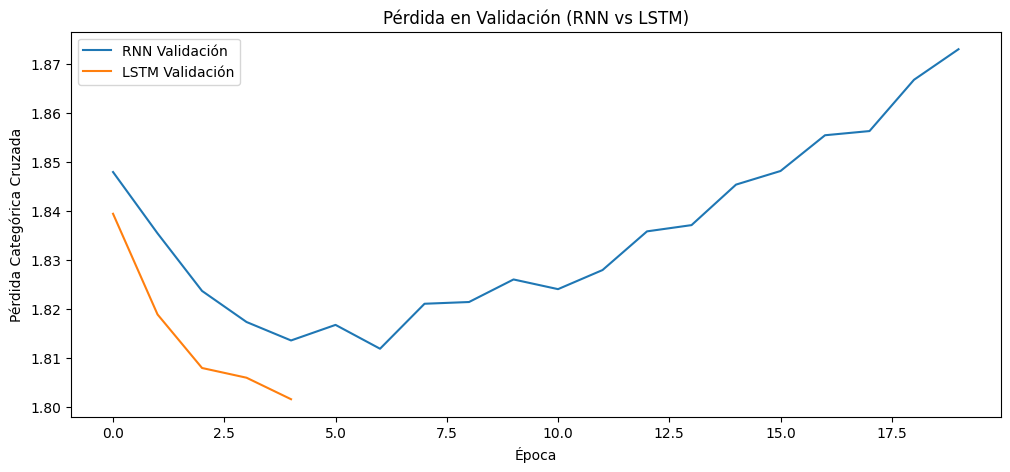

In [22]:

# Comparar rendimiento
print("\n--- Comparación RNN vs LSTM ---")
loss_rnn, acc_rnn = model_rnn.evaluate(X_test, y_test, verbose=0)
loss_lstm, acc_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)

print(f"RNN -> Loss: {loss_rnn:.4f}, Accuracy: {acc_rnn:.4f}")
print(f"LSTM -> Loss: {loss_lstm:.4f}, Accuracy: {acc_lstm:.4f}")

# %%
# Visualización de la Pérdida 
plt.figure(figsize=(12, 5))
plt.plot(history_rnn.history['val_loss'], label='RNN Validación')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validación')
plt.title('Pérdida en Validación (RNN vs LSTM)')
plt.ylabel('Pérdida Categórica Cruzada')
plt.xlabel('Época')
plt.legend()
plt.show()


--- Comparación RNN vs LSTM ---
RNN -> Loss: 1.7992, Accuracy: 0.7248
LSTM -> Loss: 1.7910, Accuracy: 0.7249


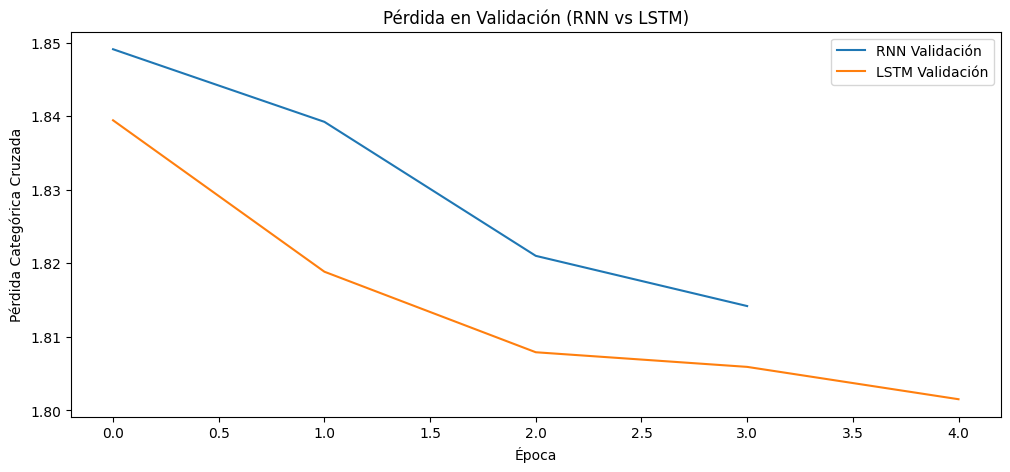

In [24]:

# Comparar rendimiento
print("\n--- Comparación RNN vs LSTM ---")
loss_rnn, acc_rnn = model_rnn.evaluate(X_test, y_test, verbose=0)
loss_lstm, acc_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)

print(f"RNN -> Loss: {loss_rnn:.4f}, Accuracy: {acc_rnn:.4f}")
print(f"LSTM -> Loss: {loss_lstm:.4f}, Accuracy: {acc_lstm:.4f}")

# %%
# Visualización de la Pérdida 
plt.figure(figsize=(12, 5))
plt.plot(history_rnn.history['val_loss'], label='RNN Validación')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validación')
plt.title('Pérdida en Validación (RNN vs LSTM)')
plt.ylabel('Pérdida Categórica Cruzada')
plt.xlabel('Época')
plt.legend()
plt.show()

In [28]:
# %% [markdown]
# ### 4.1 Definición de la Arquitectura (CORREGIDA)
# 
# **Corrección:** Usar tf.keras.layers.Lambda para envolver tf.expand_dims en la entrada del Decoder.

# %%
# Parámetros (reafirmados)
latent_dim = 150 
EMBEDDING_DIM = 200
# VOCAB_SIZE y MAX_LEN ya están definidos.

# === 1. Encoder ===
encoder_inputs = Input(shape=(MAX_LEN,), name='encoder_input')
enc_emb = Embedding(VOCAB_SIZE, EMBEDDING_DIM, name='encoder_embedding')(encoder_inputs)

encoder_outputs, state_h, state_c = LSTM(
    latent_dim, 
    return_sequences=True, 
    return_state=True, 
    name='encoder_lstm'
)(enc_emb)
encoder_states = [state_h, state_c] 

# === 2. Decoder ===
decoder_input_h = Input(shape=(latent_dim,), name='decoder_input_h')

# ✅ SOLUCIÓN AL ERROR: Envolver tf.expand_dims en una capa Lambda
# Transforma (batch, latent_dim) a (batch, 1, latent_dim)
decoder_outputs_h_expanded = tf.keras.layers.Lambda(
    lambda x: tf.expand_dims(x, 1),
    name='expand_decoder_input'
)(decoder_input_h)


# LSTM del Decoder: 
decoder_lstm = LSTM(
    latent_dim, 
    return_sequences=True, 
    name='decoder_lstm'
)
decoder_outputs = decoder_lstm(decoder_outputs_h_expanded, 
                               initial_state=encoder_states)

# === 3. Mecanismo de Atención ===
attention_layer = Attention(name='attention_mechanism')
attn_output = attention_layer([decoder_outputs, encoder_outputs])

merge = Concatenate(axis=-1, name='concat_attention_decoder')([decoder_outputs, attn_output])

# ✅ Squeeze envuelto en Lambda
squeezed = tf.keras.layers.Lambda(
    lambda x: tf.squeeze(x, axis=1),
    name='squeeze_merge'
)(merge)

# Capa de salida
dense_output = Dense(VOCAB_SIZE, activation='softmax', name='output_softmax')(squeezed)


# Modelo final
model_seq2seq_att = Model(inputs=[encoder_inputs, decoder_input_h], outputs=dense_output)

model_seq2seq_att.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_seq2seq_att.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_h     │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 10, 200)   │     40,200 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_decoder_inp… │ (None, 1, 150)    │          0 │ decoder_input_h[… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 10, 150), │    210,600 │ encoder_embeddin… │
│                     │ (None, 150),      │            │                   │
│                     │ (None, 150)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ (None, 1, 150)    │    180,600 │ expand_decoder_i… │
│                     │                   │            │ encoder_lstm[0][… │
│                     │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mechanism │ (None, 1, 150)    │          0 │ decoder_lstm[0][… │
│ (Attention)         │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_attention_d… │ (None, 1, 300)    │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ attention_mechan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ squeeze_merge       │ (None, 300)       │          0 │ concat_attention… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_softmax      │ (None, 201)       │     60,501 │ squeeze_merge[0]… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 491,901 (1.88 MB)

 Trainable params: 491,901 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:

# %% [markdown]
# ### 4.2 Entrenamiento del Modelo con Atención

# %%
# Preparación de datos para la entrada del Decoder
# La entrada `decoder_input_h` se inicializa con ceros (simulando el inicio del decoding)
# La red aprenderá a usar el estado del Encoder (propagado vía initial_state)
X_train_decoder_input = np.zeros((X_train.shape[0], latent_dim))

print("Entrenando Seq2Seq con Atención (Input shape: {})".format(model_seq2seq_att.input_shape))
history_att = model_seq2seq_att.fit(
    [X_train, X_train_decoder_input], # [Input del Encoder, Input del Decoder]
    y_train, 
    epochs=10, 
    batch_size=256, 
    validation_split=0.1, 
    verbose=1
)

# %% [markdown]
# ### 4.3 Evaluación y Comparación Final

# %%
print("\n--- Evaluación del Modelo Seq2Seq con Atención ---")
loss_att, acc_att = model_seq2seq_att.evaluate([X_test, np.zeros((X_test.shape[0], latent_dim))], y_test, verbose=0)

print(f"Seq2Seq + Atención -> Loss: {loss_att:.4f}, Accuracy: {acc_att:.4f}")

# Re-evaluar los modelos anteriores para una comparación limpia
loss_rnn, acc_rnn = model_rnn.evaluate(X_test, y_test, verbose=0)
loss_lstm, acc_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)

print(f"\nRNN (Línea Base) -> Accuracy: {acc_rnn:.4f}")
print(f"LSTM -> Accuracy: {acc_lstm:.4f}")
print(f"Seq2Seq + Atención -> Accuracy: {acc_att:.4f}")


Entrenando Seq2Seq con Atención (Input shape: [(None, 10), (None, 150)])
Epoch 1/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 49s 82ms/step - accuracy: 0.7232 - loss: 1.8866 - val_accuracy: 0.7204 - val_loss: 1.8532
Epoch 2/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 52s 92ms/step - accuracy: 0.7252 - loss: 1.8091 - val_accuracy: 0.7204 - val_loss: 1.8307
Epoch 3/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 53s 94ms/step - accuracy: 0.7258 - loss: 1.7887 - val_accuracy: 0.7211 - val_loss: 1.8153
Epoch 4/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 31s 54ms/step - accuracy: 0.7259 - loss: 1.7743 - val_accuracy: 0.7207 - val_loss: 1.8069
Epoch 5/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 56s 81ms/step - accuracy: 0.7261 - loss: 1.7630 - val_accuracy: 0.7213 - val_loss: 1.8046
Epoch 6/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 43s 75ms/step - accuracy: 0.7260 - loss: 1.7529 - val_accuracy: 0.7206 - val_loss: 1.7983
Epoch 7/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.7262 - loss: 1.7448 - val_accuracy: 0.7215 - val_loss: 1.8015
Epoch 8/10
566/56

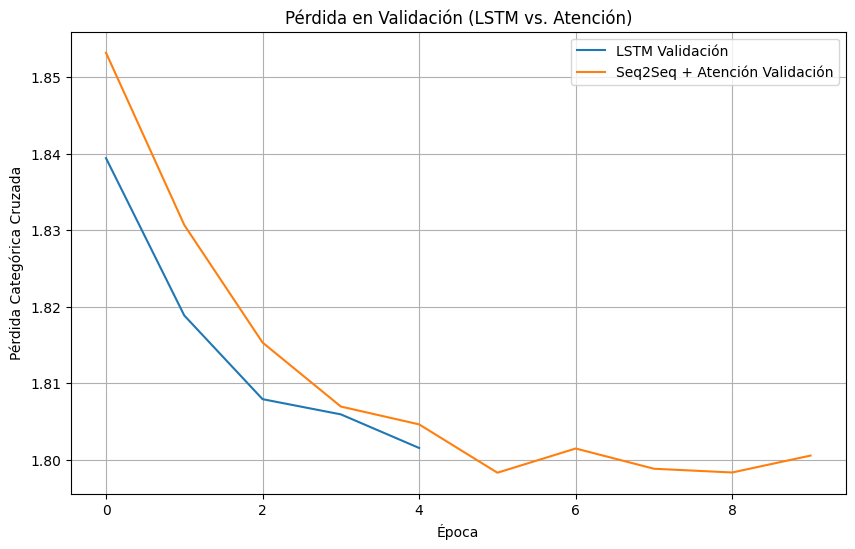

In [30]:

# %%
# Visualización de la Pérdida 
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['val_loss'], label='LSTM Validación')
plt.plot(history_att.history['val_loss'], label='Seq2Seq + Atención Validación')
plt.title('Pérdida en Validación (LSTM vs. Atención)')
plt.ylabel('Pérdida Categórica Cruzada')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Modelo auxiliar para extraer los pesos de atención
attention_extractor = Model(
    inputs=[encoder_inputs, decoder_input_h],
    outputs=attn_output,                     
    name="attention_extractor"
)


In [32]:
def get_attention_weights(input_sequence):
    """
    input_sequence: vector tokenizado shape (MAX_LEN,)
    """
    input_sequence = np.expand_dims(input_sequence, axis=0)

    # Decoder input = vector de ceros
    decoder_initial = np.zeros((1, latent_dim))

    attention_matrix = attention_extractor.predict([input_sequence, decoder_initial])
    
    # attention_matrix shape: (1, 1, MAX_LEN)
    return attention_matrix.squeeze(0).squeeze(0)  # -> (MAX_LEN,)


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_attention(tokens_in, attention_weights, title="Mapa de Atención"):
    plt.figure(figsize=(12, 1.2))
    sns.heatmap(
        [attention_weights], 
        cmap="viridis", 
        xticklabels=tokens_in,
        yticklabels=["Atención"],
        cbar=True
    )
    plt.title(title)
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


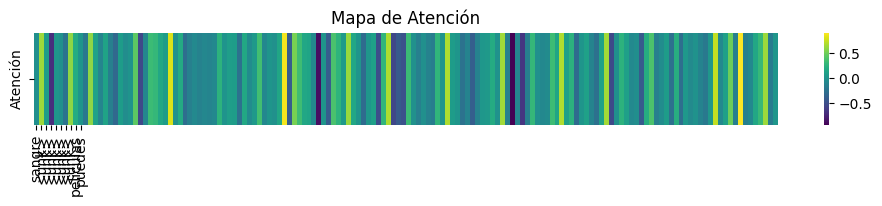

In [40]:
example_idx = 1000
sample_input = X_test[example_idx]
sample_attention = get_attention_weights(sample_input)

# Convertir IDs a palabras si tienes tokenizer
tokens_in = [tokenizer.index_word.get(i, "") for i in sample_input]

plot_attention(tokens_in, sample_attention)


In [41]:
!pip3.10 install nltk rouge-score


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24972 sha256=26cd29146a64e940a6b5afdc9f545ff3315ef716ebfdf147bb470f464aed59f4
  Stored in directory: c:\users\rentt\appdata\local\pip\cache\wheels\5f\dd\89\461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge-score



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: C:\Users\rentt\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [42]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def evaluate_bleu(model, X, y_true, n_samples=200):
    smoothie = SmoothingFunction().method4
    scores = []

    for i in range(n_samples):
        inp = X[i:i+1]
        decoder_init = np.zeros((1, latent_dim))
        pred = model.predict([inp, decoder_init], verbose=0)
        pred_token = np.argmax(pred)

        ref = [np.argmax(y_true[i])]
        
        score = sentence_bleu(
            [ref],
            [pred_token],
            smoothing_function=smoothie
        )
        scores.append(score)
    
    return np.mean(scores)


In [43]:
from rouge_score import rouge_scorer

def evaluate_rouge(model, X, y_true, n_samples=200):
    scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=True)
    scores = []

    for i in range(n_samples):
        inp = X[i:i+1]
        decoder_init = np.zeros((1, latent_dim))
        pred = model.predict([inp, decoder_init], verbose=0)
        pred_token = np.argmax(pred)

        ref = str(np.argmax(y_true[i]))
        hyp = str(pred_token)

        score = scorer.score(ref, hyp)['rouge1'].fmeasure
        scores.append(score)

    return np.mean(scores)


In [44]:
print("\n--- Evaluación del Modelo Seq2Seq con Atención ---")
loss_att, acc_att = model_seq2seq_att.evaluate(
    [X_test, np.zeros((X_test.shape[0], latent_dim))], y_test, verbose=0
)

print(f"Seq2Seq + Atención -> Loss: {loss_att:.4f}, Accuracy: {acc_att:.4f}")

# Modelos base
loss_rnn, acc_rnn = model_rnn.evaluate(X_test, y_test, verbose=0)
loss_lstm, acc_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)

print("\n--- Comparación de Accuracy ---")
print(f"RNN Base         -> Accuracy: {acc_rnn:.4f}")
print(f"LSTM             -> Accuracy: {acc_lstm:.4f}")
print(f"Seq2Seq+Att      -> Accuracy: {acc_att:.4f}")

print("\n--- Evaluación BLEU y ROUGE (200 muestras) ---")
bleu_att = evaluate_bleu(model_seq2seq_att, X_test, y_test)
rouge_att = evaluate_rouge(model_seq2seq_att, X_test, y_test)

print(f"BLEU  (Att):  {bleu_att:.4f}")
print(f"ROUGE1(Att):  {rouge_att:.4f}")



--- Evaluación del Modelo Seq2Seq con Atención ---
Seq2Seq + Atención -> Loss: 1.7919, Accuracy: 0.7247

--- Comparación de Accuracy ---
RNN Base         -> Accuracy: 0.7248
LSTM             -> Accuracy: 0.7249
Seq2Seq+Att      -> Accuracy: 0.7247

--- Evaluación BLEU y ROUGE (200 muestras) ---
BLEU  (Att):  0.7100
ROUGE1(Att):  0.7100


In [ ]:
!pip3.10 install spacy coreferee
!python -m spacy download es_core_news_md
!python -m coreferee install es

## Resolución de Co-referencia

In [ ]:
# Pronombres de tercera persona en español (formas básicas)
THIRD_PERSON_PRONOUNS = {
    "él", "ella", "ellos", "ellas",
    "Él", "Ella", "Ellos", "Ellas"
}

def get_gender_number(token):
    """
    Devuelve (gender, number) para un token usando los rasgos morfológicos de spaCy.
    gender: 'Masc', 'Fem', ...
    number: 'Sing', 'Plur', ...
    Si no se detecta, devuelve None.
    """
    morph = token.morph
    g = morph.get("Gender")
    n = morph.get("Number")
    gender = g[0] if g else None
    number = n[0] if n else None
    return gender, number


def is_potential_antecedent(token):
    """
    Consideramos como posibles antecedentes:
    - Entidades PERSON
    - Nombres propios (PROPN)
    - Sustantivos (NOUN) con rasgos de género/número
    """
    if token.ent_type_ == "PER":
        return True
    if token.pos_ in ["PROPN", "NOUN"] and token.is_alpha:
        return True
    return False

### Resolución de co-referencia a nivel de documento

In [ ]:
def resolve_coreference_in_doc(doc, max_sent_distance=3):
    """
    Resuelve co-referencias de tercera persona en un objeto Doc de spaCy.
    Estrategia:
    - Recorremos las oraciones en orden.
    - Vamos almacenando candidatos a antecedente con su género/número y el índice de oración.
    - Cuando encontramos un pronombre de 3ª persona, buscamos hacia atrás el antecedente
      más cercano que concuerde en género/número dentro de max_sent_distance oraciones.
    - Construimos un nuevo texto sustituyendo el pronombre por el antecedente.
    
    Nota: es un enfoque heurístico y simplificado.
    """
    # Lista para guardar info de antecedentes
    # cada antecedente será un dict con:
    # {"text": str, "gender": str or None, "number": str or None, "sent_id": int}
    antecedents = []

    # Guardaremos los tokens resueltos preservando espacios
    resolved_tokens = []

    # Mapeo de token -> índice de oración
    sent_ids = {}
    for sent_id, sent in enumerate(doc.sents):
        for token in sent:
            sent_ids[token.i] = sent_id

    for token in doc:
        sent_id = sent_ids[token.i]

        # Registrar posibles antecedentes
        if is_potential_antecedent(token):
            g, n = get_gender_number(token)
            antecedents.append({
                "text": token.text,
                "gender": g,
                "number": n,
                "sent_id": sent_id
            })

        # Si es un pronombre de 3ª persona, tratamos de resolverlo
        if token.text in THIRD_PERSON_PRONOUNS:
            g_p, n_p = get_gender_number(token)

            best_ant = None
            # Buscar hacia atrás en la lista de antecedentes
            for ant in reversed(antecedents):
                # si está demasiado lejos en número de oraciones, paramos
                if sent_id - ant["sent_id"] > max_sent_distance:
                    break

                # Comprobamos concordancia de género y número (si están disponibles)
                gender_ok = (g_p is None or ant["gender"] is None or ant["gender"] == g_p)
                number_ok = (n_p is None or ant["number"] is None or ant["number"] == n_p)

                if gender_ok and number_ok:
                    best_ant = ant
                    break

            if best_ant is not None:
                # Sustituimos el pronombre por el antecedente
                new_text = best_ant["text"]
            else:
                # Si no hay antecedente, dejamos el pronombre tal cual
                new_text = token.text

            resolved_tokens.append(new_text + token.whitespace_)
        else:
            # Token normal, se copia tal cual
            resolved_tokens.append(token.text + token.whitespace_)

    resolved_text = "".join(resolved_tokens)
    return resolved_text


In [ ]:
def resolve_coreference(text: str, nlp_pipeline=nlp, max_sent_distance=3) -> str:
    """
    Wrapper: recibe un texto en bruto, lo procesa con spaCy y aplica la resolución
    de co-referencia heurística.
    """
    doc = nlp_pipeline(text)
    resolved = resolve_coreference_in_doc(doc, max_sent_distance=max_sent_distance)
    return resolved

### Ejemplo ilustrativo

In [ ]:
example_text = "Pulgarcito fue al mercado. Él compró frutas. Luego él regresó a casa muy contento."
resolved_example = resolve_coreference(example_text)

print("Texto original:")
print(example_text)
print("\nTexto con co-referencia resuelta:")
print(resolved_example)

Texto original:
Pulgarcito fue al mercado. Él compró frutas. Luego él regresó a casa muy contento.

Texto con co-referencia resuelta:
Pulgarcito fue al mercado. mercado compró frutas. Luego mercado regresó a casa muy contento.
